# 02 · Preprocessing and per-tier feature selection

Everything is **fitted on the training isolates only** and then applied to the test isolates.

| Step | Method | Figure |
|---|---|---|
| Missing values | audit, MCAR check, imputer comparison (grouped CV), median / mode imputation | 11, 12 |
| Outliers | Tukey IQR fences (1.5 × IQR), winsorisation | 13 |
| Normalisation | log10 for counts, then z-score | 14 |
| Correlation | Spearman, clustered; redundancy filter at abs(rho) > 0.95 | 15 |
| Feature selection | per tier: FDR q < 0.05 **and** mutual information ≥ 0.01 **and** non-redundant | 16 |

**Leakage guard:** `Organism` and `Resistance_Marker` are never candidates for Tier 1, because both reveal the Gram reaction.

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/gram-id-ast-ml


In [2]:
# Rebuild the isolate-grouped splits if they are missing (fresh clone)
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()

from src.data.make_dataset import load_split, get_xy
from src.features import build_features as bf
train, test = load_split("train"), load_split("test")
print("train", train.shape, train[cfg.ISOLATE_ID].nunique(), "isolates | test", test.shape, test[cfg.ISOLATE_ID].nunique(), "isolates")
print("isolates shared between splits:", len(set(train[cfg.ISOLATE_ID]) & set(test[cfg.ISOLATE_ID])))

train (5780, 30) 219 isolates | test (1540, 30) 55 isolates
isolates shared between splits: 0


In [3]:
for tier, feats in cfg.TIER_CANDIDATES.items():
    print(f"{tier}: {len(feats)} candidates -> {feats}")

tier1_gram: 10 candidates -> ['Crystal_Violet_Retention', 'Safranin_Intensity', 'Stain_Hue_Angle_deg', 'Cell_Wall_Thickness_nm', 'Mean_Cell_Area_um2', 'Cell_Elongation_Index', 'KOH_String_Test', 'Cell_Morphology', 'Catalase', 'Specimen_Source']
tier2_growth: 15 candidates -> ['Concentration_ug_mL', 'Well_DSI', 'Incubation_Time_h', 'Inoculum_log10_CFU_mL', 'Cell_Count_T0', 'Cell_Count_T4h', 'Growth_Fold_Change', 'Mean_Cell_Area_um2', 'Cell_Elongation_Index', 'Occupied_Area_Fraction', 'Time_to_Detection_h', 'OD600_Read', 'Growth_Control_OD600', 'Antimicrobial', 'Specimen_Source']


## 1. Missing values

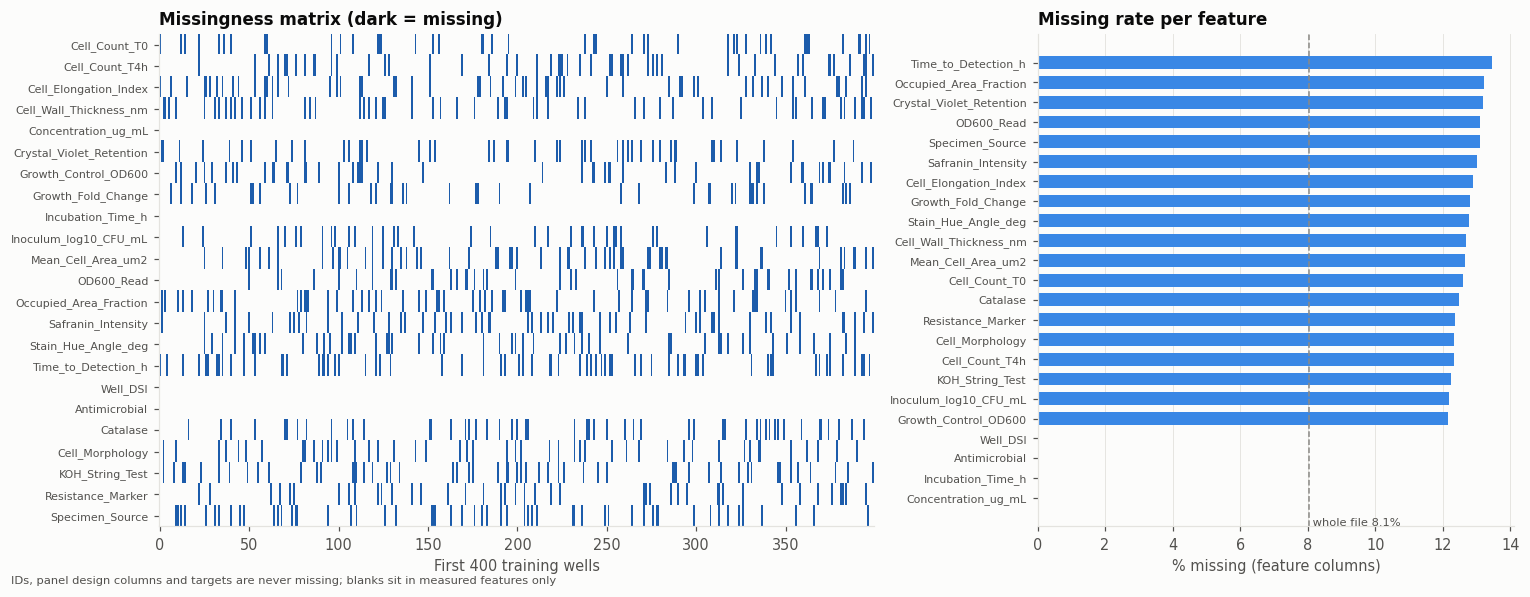

In [4]:
bf.plot_missingness(train);

In [5]:
mbt = bf.missing_by_target(train)
print("features whose missingness depends on the label (p < 0.05):", int((mbt.chi2_p < .05).sum()), "of", len(mbt))
mbt.round(4).head(8)

features whose missingness depends on the label (p < 0.05): 2 of 25


,tier,feature,missing_neg,missing_pos,chi2_p
0,tier1_gram,Crystal_Violet_Retention,0.1325,0.1313,0.9202
1,tier1_gram,Safranin_Intensity,0.1352,0.1259,0.3146
2,tier1_gram,Stain_Hue_Angle_deg,0.1237,0.1313,0.4136
3,tier1_gram,Cell_Wall_Thickness_nm,0.1310,0.1234,0.4096
4,tier1_gram,Mean_Cell_Area_um2,0.1398,0.1158,0.0072
5,tier1_gram,Cell_Elongation_Index,0.1291,0.1287,1.0000
6,tier1_gram,KOH_String_Test,0.1279,0.1177,0.2545
7,tier1_gram,Cell_Morphology,0.1306,0.1174,0.1388


## 2. Feature selection (run first so the imputer comparison uses the final feature sets)

In [6]:
sel, tables = {}, {}
for tier in cfg.TIERS:
    r = bf.select_features(train, tier)
    sel[tier], tables[tier] = r["selected"], r["table"]
    print(f"{tier}: kept {len(r['selected'])} -> {r['selected']}")

tier1_gram: kept 9 -> ['Crystal_Violet_Retention', 'Safranin_Intensity', 'Stain_Hue_Angle_deg', 'Cell_Wall_Thickness_nm', 'Mean_Cell_Area_um2', 'Cell_Elongation_Index', 'KOH_String_Test', 'Cell_Morphology', 'Catalase']


tier2_growth: kept 9 -> ['Growth_Fold_Change', 'Time_to_Detection_h', 'Occupied_Area_Fraction', 'OD600_Read', 'Well_DSI', 'Cell_Elongation_Index', 'Mean_Cell_Area_um2', 'Inoculum_log10_CFU_mL', 'Antimicrobial']


In [7]:
pd.concat(tables.values())[["tier", "feature", "type", "q_value", "mutual_info", "reason"]].round(5)

,tier,feature,type,q_value,mutual_info,reason
0,tier1_gram,Cell_Elongation_Index,numeric,0.00000,0.48380,kept
1,tier1_gram,Mean_Cell_Area_um2,numeric,0.00000,0.48107,kept
2,tier1_gram,KOH_String_Test,categorical,0.00000,0.38793,kept
3,tier1_gram,Crystal_Violet_Retention,numeric,0.00000,0.37564,kept
4,tier1_gram,Safranin_Intensity,numeric,0.00000,0.31966,kept
5,tier1_gram,Cell_Morphology,categorical,0.00000,0.30861,kept
6,tier1_gram,Stain_Hue_Angle_deg,numeric,0.00000,0.26681,kept
7,tier1_gram,Cell_Wall_Thickness_nm,numeric,0.00000,0.25828,kept
8,tier1_gram,Catalase,categorical,0.00000,0.10519,kept
9,tier1_gram,Specimen_Source,categorical,0.00000,0.00601,dropped: mutual information < 0.01


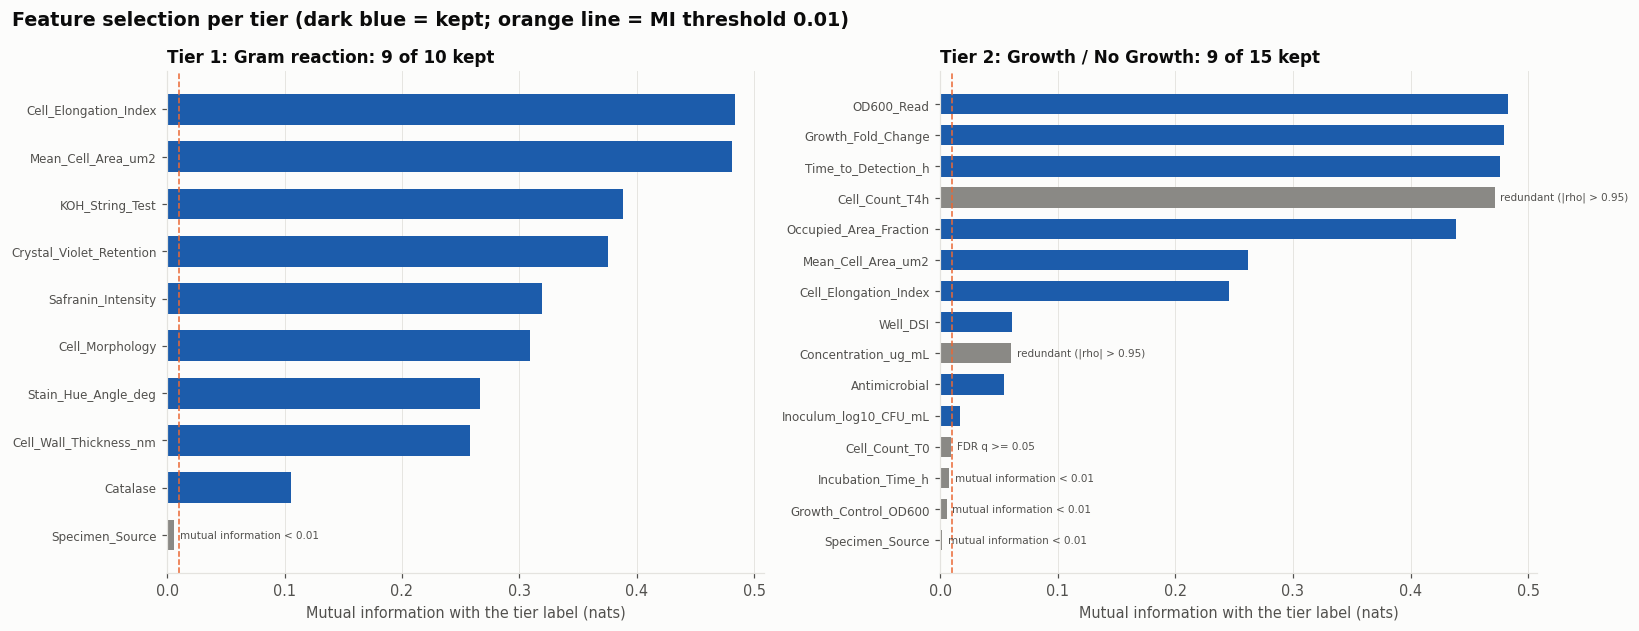

In [8]:
bf.plot_feature_selection(tables);

## 3. Imputation strategy

In [9]:
imp = bf.compare_imputers(train, sel)
imp.round(4)

,tier,imputer,cv_auc_mean,cv_auc_sd
0,tier1_gram,mean,0.9965,0.0015
1,tier1_gram,median,0.9965,0.0014
2,tier1_gram,knn,0.9967,0.0014
3,tier1_gram,iterative,0.9970,0.0014
4,tier2_growth,mean,0.9981,0.0005
5,tier2_growth,median,0.9975,0.0005
6,tier2_growth,knn,0.9980,0.0008
7,tier2_growth,iterative,0.9979,0.0007


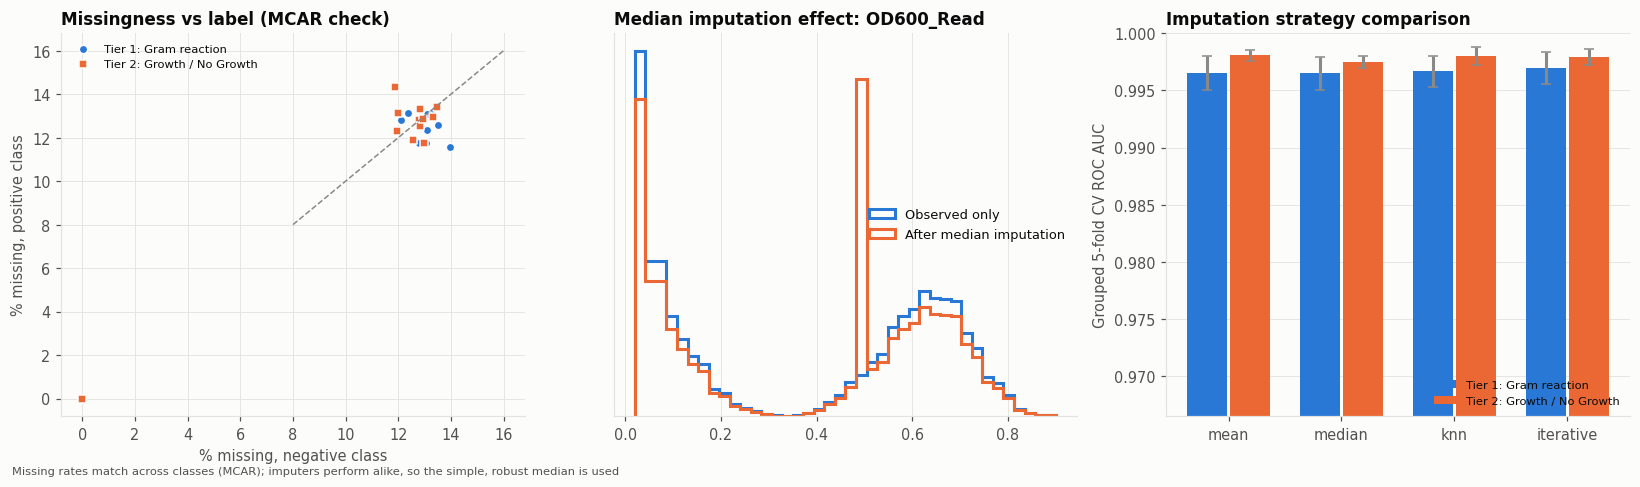

In [10]:
bf.plot_missing_handling(train, mbt, imp);

Missingness looks random with respect to both labels, and all four imputers are within about 0.001 AUC of each other. **Median imputation** is used: simple, robust and easy to reproduce in production.

## 4. Outlier analysis

In [11]:
otab = bf.outlier_table(train)
otab.round(3)

,feature,lower_fence,upper_fence,n_low,n_high,pct_outliers,n_abs_z_gt_3
2,Cell_Elongation_Index,-1.448,5.710,0,950,18.868,17
8,Incubation_Time_h,18.000,18.000,0,616,10.657,0
4,Concentration_ug_mL,-11.375,19.625,0,543,9.394,157
0,Cell_Count_T0,1.979,2.364,72,2,1.465,33
9,Inoculum_log10_CFU_mL,5.380,6.020,14,32,0.906,18
6,Growth_Control_OD600,0.567,1.039,30,0,0.591,5
14,Stain_Hue_Angle_deg,254.450,347.650,0,1,0.020,1
3,Cell_Wall_Thickness_nm,-10.750,50.450,0,0,0.000,0
1,Cell_Count_T4h,0.724,4.727,0,0,0.000,0
7,Growth_Fold_Change,-1.479,2.581,0,0,0.000,0


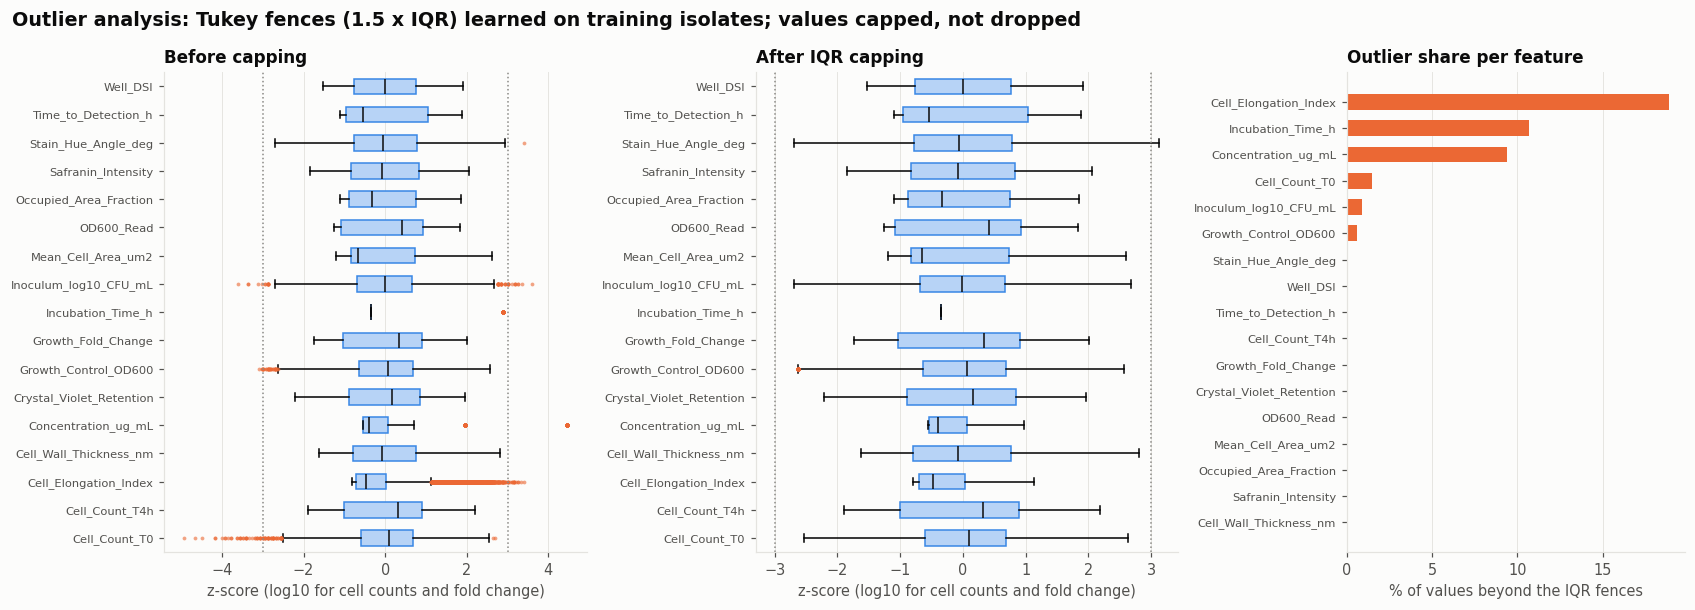

In [12]:
bf.plot_outliers(train, otab);

## 5. z-score normalisation

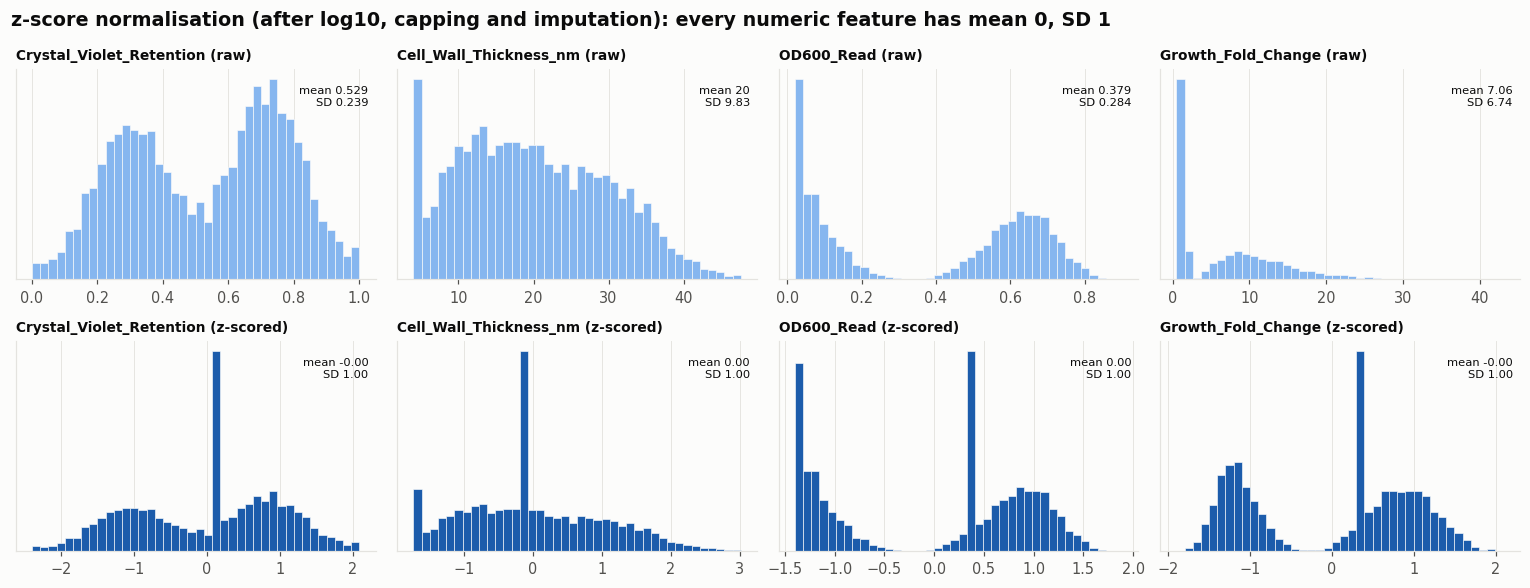

In [13]:
bf.plot_zscore(train, sel);

## 6. Correlation analysis

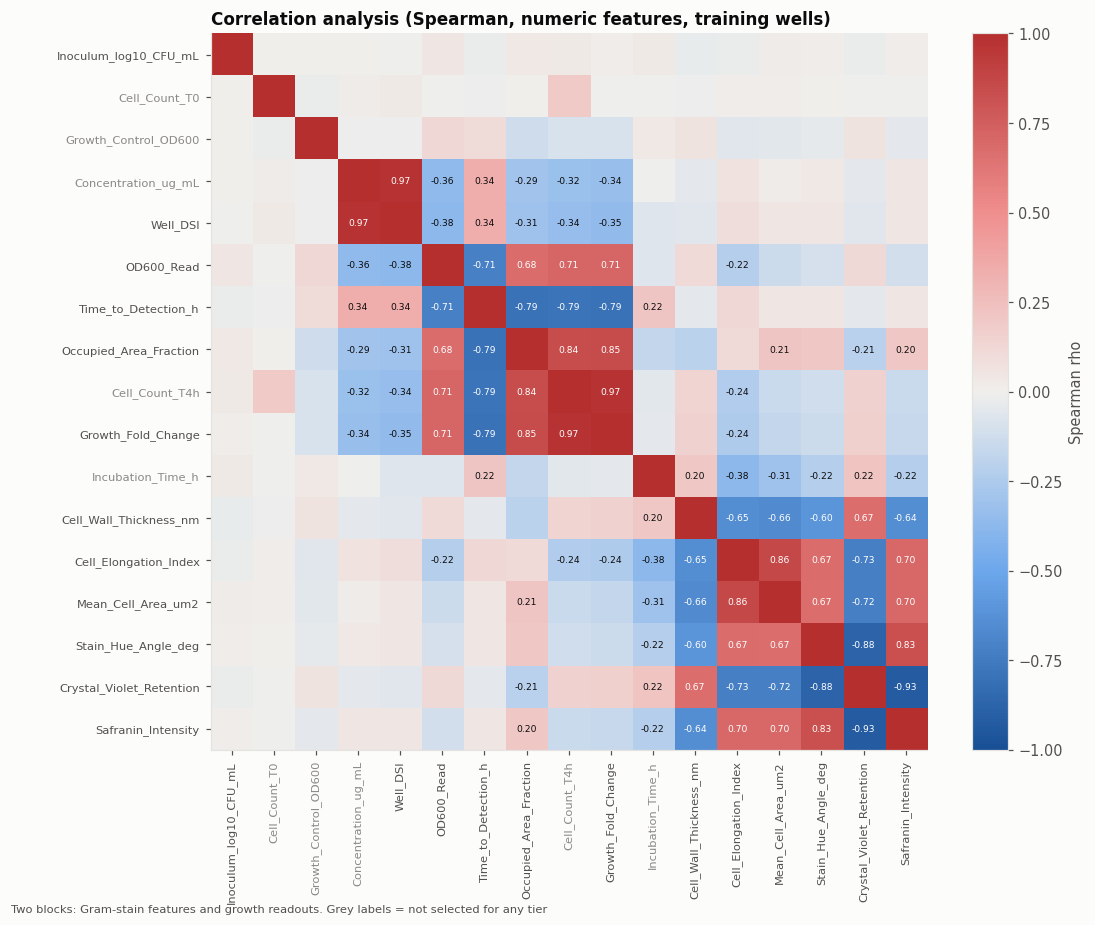

In [14]:
bf.plot_correlation(train, sel);

Two correlated blocks appear: the Gram-stain features and the growth readouts. Only near-duplicates (abs(rho) > 0.95) are removed, for example cell count at 4 h vs fold change. The remaining correlated features are kept on purpose, because redundancy makes the models robust when a measurement is missing.

## 7. The final preprocessing pipeline

In [15]:
num, cat = bf.split_types(sel["tier2_growth"])
prep = bf.build_preprocessor(num, cat)
prep

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('log10', ...), ('columns', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,['Growth_Fold_Change']
,floor,0.001
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [16]:
X, _ = get_xy(train, "tier2_growth", sel["tier2_growth"])
Xt = pd.DataFrame(prep.fit_transform(X), columns=prep.get_feature_names_out())
print(Xt.shape, "| NaN left:", bool(Xt.isna().any().any()))
Xt.describe().T[["mean", "std", "min", "max"]].round(3)

(5780, 14) | NaN left: False


,mean,std,min,max
Growth_Fold_Change,-0.000,1.000,-1.896,2.093
Time_to_Detection_h,0.000,1.000,-1.086,2.070
Occupied_Area_Fraction,-0.000,1.000,-1.126,2.016
OD600_Read,0.000,1.000,-1.400,1.890
Well_DSI,0.000,1.000,-1.529,1.908
Cell_Elongation_Index,-0.000,1.000,-0.916,1.961
Mean_Cell_Area_um2,-0.000,1.000,-1.158,2.805
Inoculum_log10_CFU_mL,-0.000,1.000,-2.898,2.885
Antimicrobial_Ampicillin,0.234,0.423,0.000,1.000
Antimicrobial_Ceftriaxone,0.272,0.445,0.000,1.000


In [17]:
_ = bf.run(); plt.close("all")        # writes selected_features.json, tables, figures (as `make features`)
print(open(cfg.SELECTED_FEATURES_FILE).read()[:700])

13:40:43 | INFO    | src.features.build_features | tier1_gram: kept 9/10 -> ['Crystal_Violet_Retention', 'Safranin_Intensity', 'Stain_Hue_Angle_deg', 'Cell_Wall_Thickness_nm', 'Mean_Cell_Area_um2', 'Cell_Elongation_Index', 'KOH_String_Test', 'Cell_Morphology', 'Catalase']


13:40:43 | INFO    | src.features.build_features | tier2_growth: kept 9/15 -> ['Growth_Fold_Change', 'Time_to_Detection_h', 'Occupied_Area_Fraction', 'OD600_Read', 'Well_DSI', 'Cell_Elongation_Index', 'Mean_Cell_Area_um2', 'Inoculum_log10_CFU_mL', 'Antimicrobial']


13:40:58 | INFO    | src.features.build_features | Imputer comparison:
        tier   imputer  cv_auc_mean  cv_auc_sd
  tier1_gram      mean       0.9965     0.0015
  tier1_gram    median       0.9965     0.0014
  tier1_gram       knn       0.9967     0.0014
  tier1_gram iterative       0.9970     0.0014
tier2_growth      mean       0.9981     0.0005
tier2_growth    median       0.9975     0.0005
tier2_growth       knn       0.9980     0.0008
tier2_growth iterative       0.9979     0.0007


{
  "tier1_gram": {
    "selected_features": [
      "Crystal_Violet_Retention",
      "Safranin_Intensity",
      "Stain_Hue_Angle_deg",
      "Cell_Wall_Thickness_nm",
      "Mean_Cell_Area_um2",
      "Cell_Elongation_Index",
      "KOH_String_Test",
      "Cell_Morphology",
      "Catalase"
    ],
    "numeric": [
      "Crystal_Violet_Retention",
      "Safranin_Intensity",
      "Stain_Hue_Angle_deg",
      "Cell_Wall_Thickness_nm",
      "Mean_Cell_Area_um2",
      "Cell_Elongation_Index"
    ],
    "categorical": [
      "KOH_String_Test",
      "Cell_Morphology",
      "Catalase"
    ]
  },
  "tier2_growth": {
    "selected_features": [
      "Growth_Fold_Change",
      "Time_to_Det
